# Stage 4 — Exploratory Data Analysis
**Dataset:** Nepal Road Accident Data (Cleaned)  
**Target:** `Accident_Severity` (multi-class classification)  
**Input:** `data/03_interim/accidents_cleaned.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

INTERIM_DIR = Path('../../data/03_interim')
FIG_DIR     = Path('../../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INTERIM_DIR / 'accidents_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (1200, 15)


,Accident_ID,Accident_Date,Year,Month,Province,District,Road_Type,Intersection_Type,Time_of_Day,Accident_Severity,Weather_Condition,Road_Surface,Vehicle_Type,Speed_Zone,Driver_Gender
0,1179,2026-01-09,2026,January,Sudurpashchim,Kailali,Highway,Junction,Afternoon,Damage Only,Clear,Slippery,Scooter,50,Male
1,866,2025-03-07,2025,March,Bagmati,Chitwan,Feeder,Curve,Evening,Serious Injury,Clear,Dry,Car,50,Female
2,102,2023-03-23,2023,March,Lumbini,Kapilvastu,Urban,Straight,Morning,Damage Only,Clear,Dry,Truck,30,Male
3,440,2024-02-16,2024,February,Madhesh,Rautahat,Urban,Curve,Night,Minor Injury,Clear,Slippery,Motorbike,80,Male
4,59,2023-02-10,2023,February,Sudurpashchim,Achham,Urban,Straight,Night,Serious Injury,Clear,Wet,Scooter,50,Male


## 1. Data Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Accident_ID        1200 non-null   int64
 1   Accident_Date      1200 non-null   str  
 2   Year               1200 non-null   int64
 3   Month              1200 non-null   str  
 4   Province           1200 non-null   str  
 5   District           1200 non-null   str  
 6   Road_Type          1200 non-null   str  
 7   Intersection_Type  1200 non-null   str  
 8   Time_of_Day        1200 non-null   str  
 9   Accident_Severity  1200 non-null   str  
 10  Weather_Condition  1200 non-null   str  
 11  Road_Surface       1200 non-null   str  
 12  Vehicle_Type       1200 non-null   str  
 13  Speed_Zone         1200 non-null   int64
 14  Driver_Gender      1200 non-null   str  
dtypes: int64(3), str(12)
memory usage: 140.8 KB


In [3]:
# Quality report
quality = pd.DataFrame({
    'dtype':       df.dtypes,
    'missing':     df.isnull().sum(),
    'missing_%':   (df.isnull().mean() * 100).round(2),
    'unique':      df.nunique(),
    'sample':      df.iloc[0]
})
quality

,dtype,missing,missing_%,unique,sample
Accident_ID,int64,0,0.0,1200,1179
Accident_Date,str,0,0.0,733,2026-01-09
Year,int64,0,0.0,4,2026
Month,str,0,0.0,12,January
Province,str,0,0.0,7,Sudurpashchim
District,str,0,0.0,28,Kailali
Road_Type,str,0,0.0,4,Highway
Intersection_Type,str,0,0.0,4,Junction
Time_of_Day,str,0,0.0,4,Afternoon
Accident_Severity,str,0,0.0,4,Damage Only


In [13]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


## 2. Target Variable — Accident Severity

                   Count  Percentage
Accident_Severity                   
Minor Injury         551        45.9
Serious Injury       289        24.1
Damage Only          256        21.3
Fatal                104         8.7


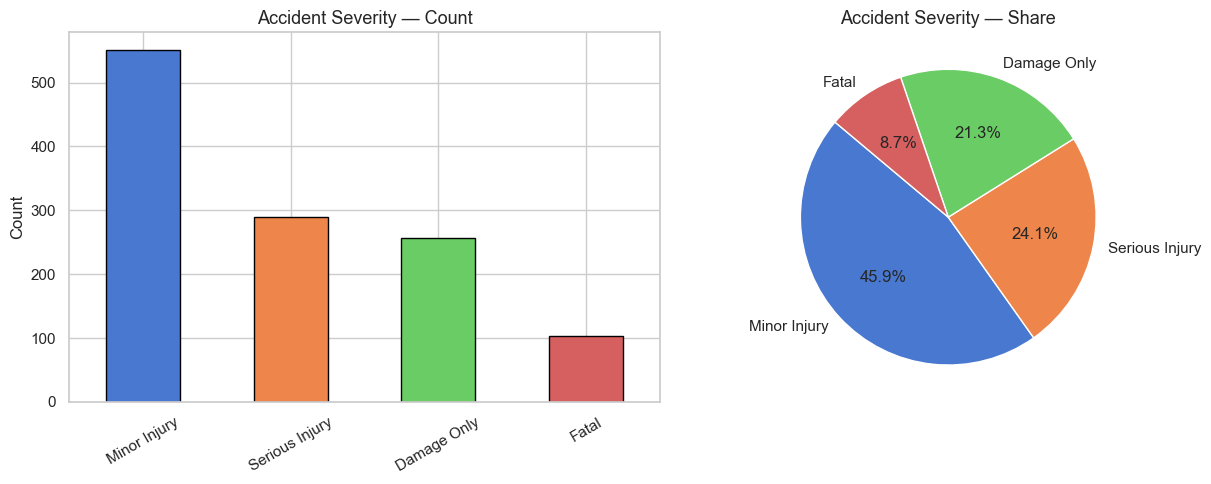

In [14]:
severity_counts = df['Accident_Severity'].value_counts()
severity_pct    = df['Accident_Severity'].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': severity_counts, 'Percentage': severity_pct.round(1)}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
severity_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'), edgecolor='black')
axes[0].set_title('Accident Severity — Count', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted'), startangle=140)
axes[1].set_title('Accident Severity — Share', fontsize=13)

plt.tight_layout()
fig.savefig(FIG_DIR / 'target_distribution.png', dpi=150)
plt.show()

## 3. Temporal Analysis

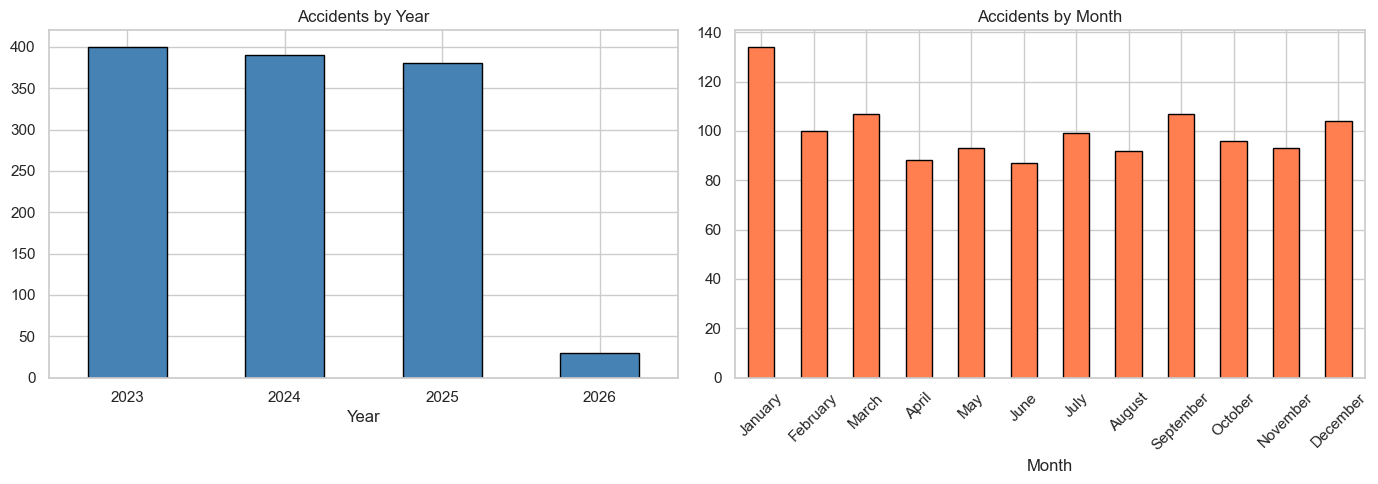

In [4]:
df['Accident_Date'] = pd.to_datetime(df['Accident_Date'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accidents by Year
df.groupby('Year')['Accident_ID'].count().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='black')
axes[0].set_title('Accidents by Year')
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=0)

# Accidents by Month
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_counts = df['Month'].value_counts().reindex(month_order, fill_value=0)
month_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Accidents by Month')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig(FIG_DIR / 'temporal_analysis.png', dpi=150)
plt.show()

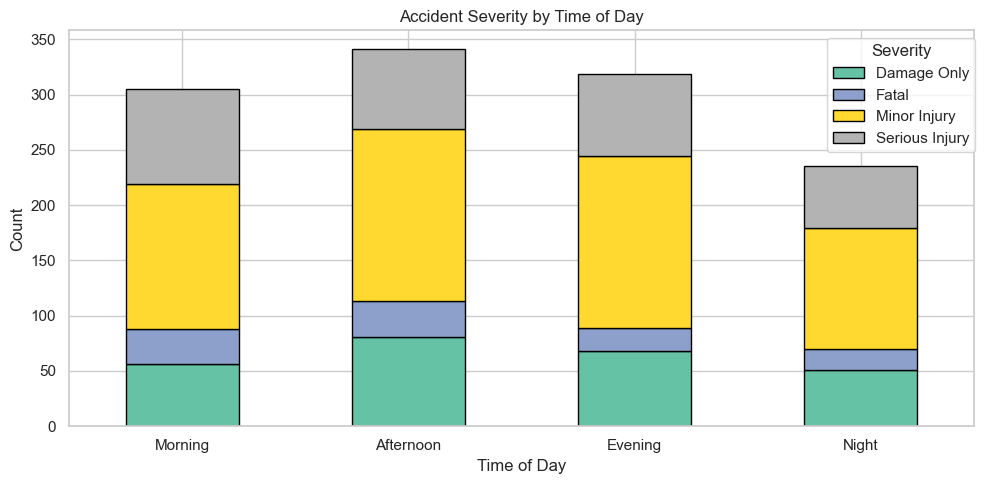

In [5]:
# Accidents by Time of Day
fig, ax = plt.subplots(figsize=(10, 5))
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod_sev = df.groupby(['Time_of_Day', 'Accident_Severity']).size().unstack(fill_value=0)
tod_sev = tod_sev.reindex(tod_order)
tod_sev.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Accident Severity by Time of Day')
ax.set_xlabel('Time of Day')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Severity', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
fig.savefig(FIG_DIR / 'severity_by_time.png', dpi=150)
plt.show()

## 4. Geographic Analysis

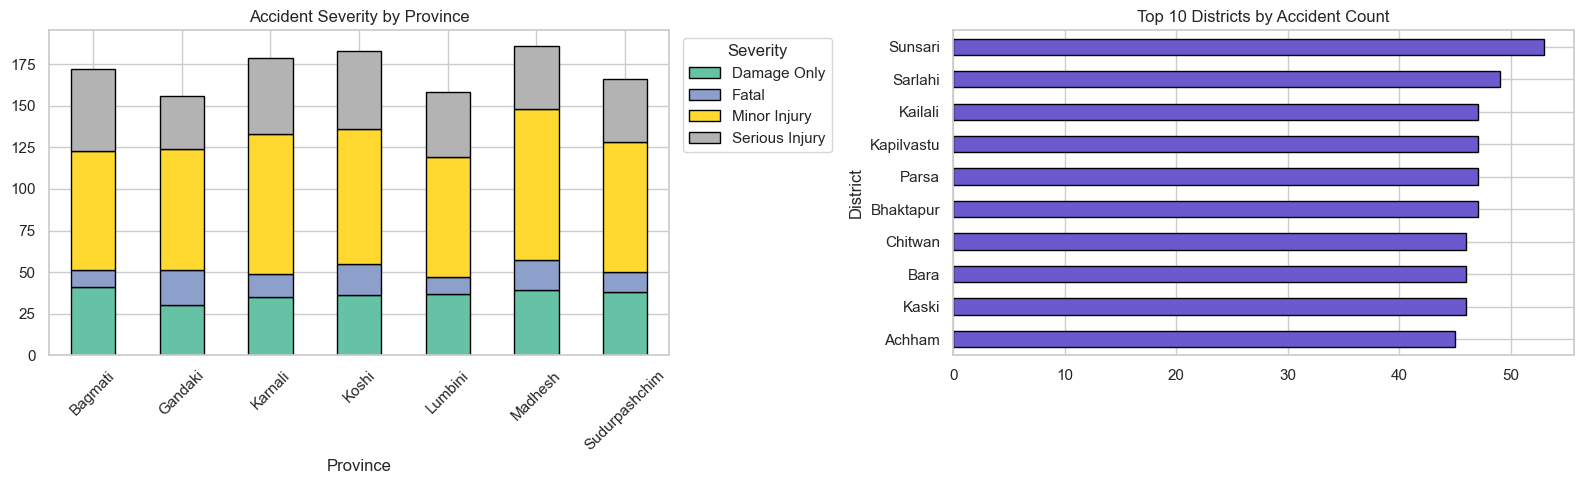

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accidents by Province
prov_sev = df.groupby(['Province', 'Accident_Severity']).size().unstack(fill_value=0)
prov_sev.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Accident Severity by Province')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Severity', bbox_to_anchor=(1.01, 1))

# Top 10 Districts
top_districts = df['District'].value_counts().head(10)
top_districts.plot(kind='barh', ax=axes[1], color='slateblue', edgecolor='black')
axes[1].set_title('Top 10 Districts by Accident Count')
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(FIG_DIR / 'geographic_analysis.png', dpi=150)
plt.show()

## 5. Road & Environmental Conditions

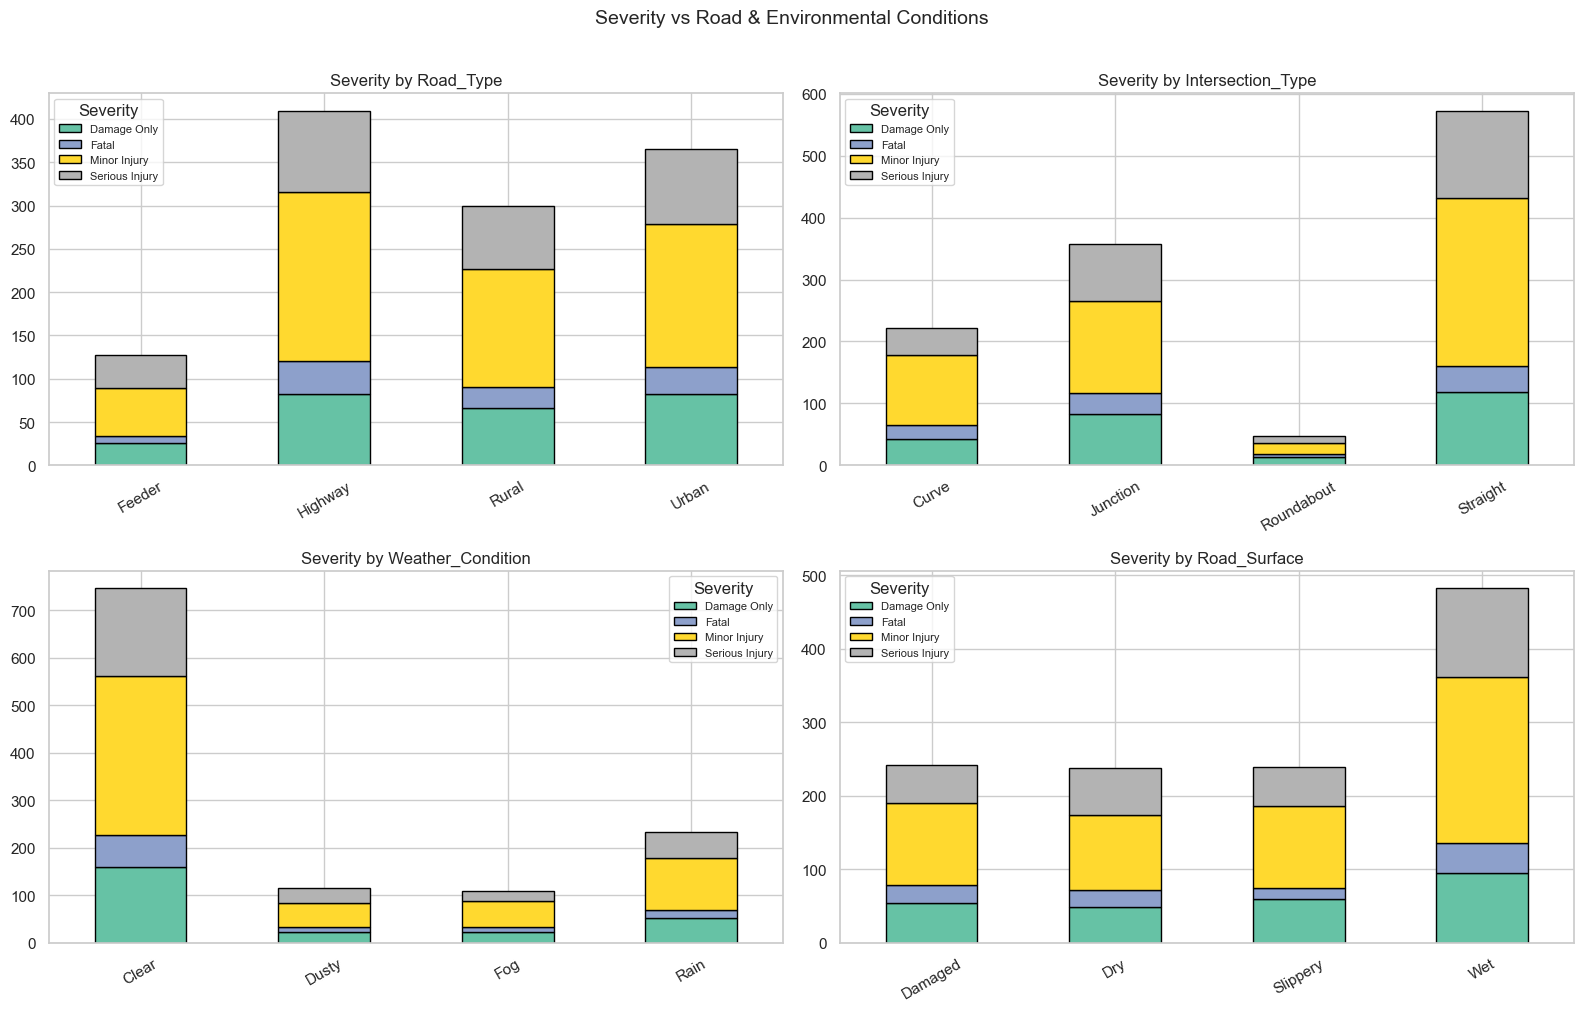

In [7]:
cat_features = ['Road_Type', 'Intersection_Type', 'Weather_Condition', 'Road_Surface']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    pivot = df.groupby([col, 'Accident_Severity']).size().unstack(fill_value=0)
    pivot.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black')
    axes[i].set_title(f'Severity by {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Severity', fontsize=8)

plt.suptitle('Severity vs Road & Environmental Conditions', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'road_env_conditions.png', dpi=150)
plt.show()

## 6. Vehicle & Driver Analysis

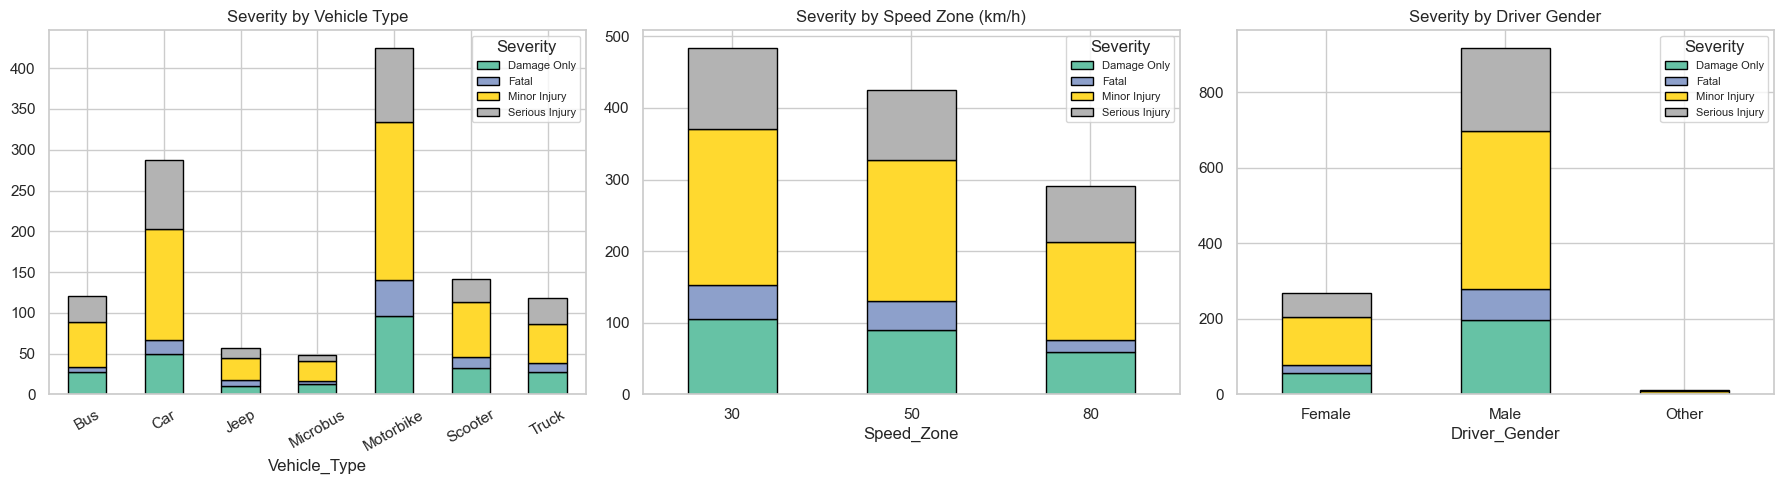

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Vehicle Type
veh_sev = df.groupby(['Vehicle_Type', 'Accident_Severity']).size().unstack(fill_value=0)
veh_sev.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Severity by Vehicle Type')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Severity', fontsize=8)

# Speed Zone
speed_sev = df.groupby(['Speed_Zone', 'Accident_Severity']).size().unstack(fill_value=0)
speed_sev.sort_index().plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('Severity by Speed Zone (km/h)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Severity', fontsize=8)

# Driver Gender
gen_sev = df.groupby(['Driver_Gender', 'Accident_Severity']).size().unstack(fill_value=0)
gen_sev.plot(kind='bar', stacked=True, ax=axes[2], colormap='Set2', edgecolor='black')
axes[2].set_title('Severity by Driver Gender')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Severity', fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / 'vehicle_driver_analysis.png', dpi=150)
plt.show()

## 7. Heatmap — Province × Time of Day

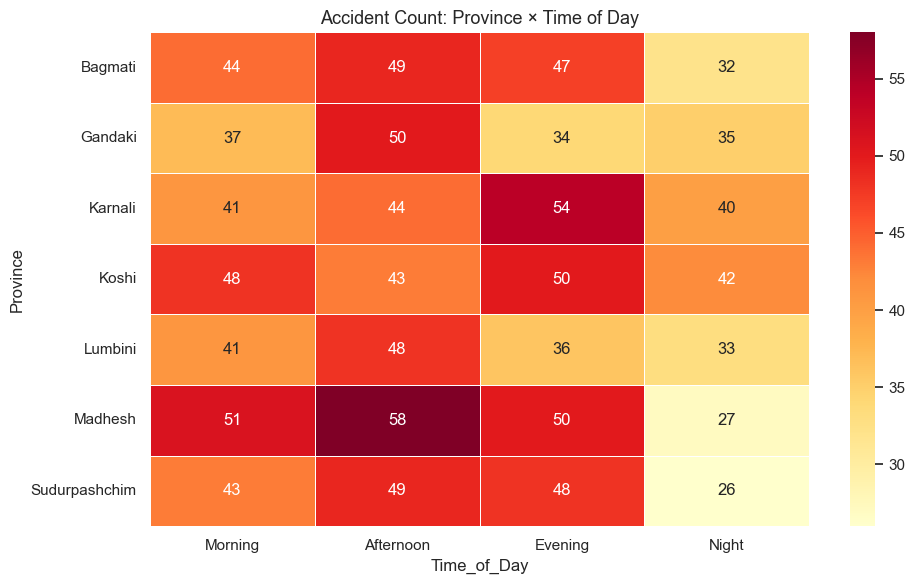

In [9]:
pivot_heat = df.groupby(['Province', 'Time_of_Day']).size().unstack(fill_value=0)
tod_order  = ['Morning', 'Afternoon', 'Evening', 'Night']
pivot_heat = pivot_heat.reindex(columns=tod_order)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_heat, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Accident Count: Province × Time of Day', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'heatmap_province_time.png', dpi=150)
plt.show()

## 8. Heatmap — Road Surface × Weather

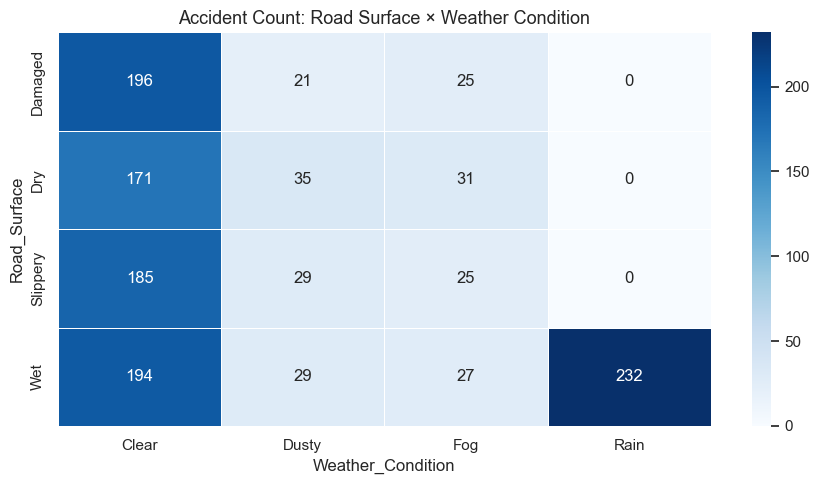

In [10]:
pivot_rw = df.groupby(['Road_Surface', 'Weather_Condition']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_rw, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Accident Count: Road Surface × Weather Condition', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'heatmap_surface_weather.png', dpi=150)
plt.show()

## 9. Province Risk Rate (Fatal + Serious / Total)

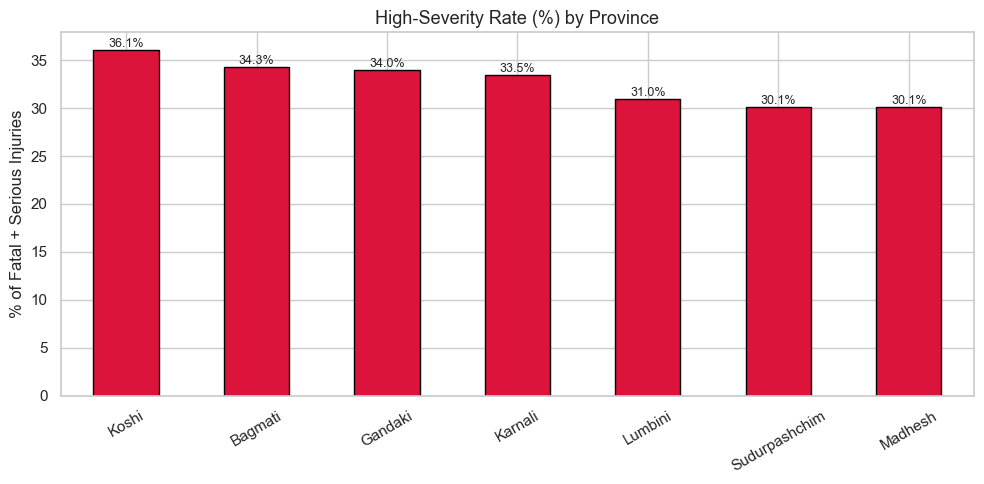

In [15]:
high_sev = ['Fatal', 'Serious Injury']
prov_total  = df.groupby('Province').size()
prov_high   = df[df['Accident_Severity'].isin(high_sev)].groupby('Province').size()
risk_rate   = (prov_high / prov_total * 100).sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
risk_rate.plot(kind='bar', color='crimson', edgecolor='black', ax=ax)
ax.set_title('High-Severity Rate (%) by Province', fontsize=13)
ax.set_ylabel('% of Fatal + Serious Injuries')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(risk_rate):
    ax.text(i, v + 0.3, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'province_risk_rate.png', dpi=150)
plt.show()

## 10. Speed Zone Distribution by Severity

/var/folders/_0/x3xnfyhs0_n4_tyyc9p5smkm0000gn/T/ipykernel_10519/2620706125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Accident_Severity', y='Speed_Zone', order=order,


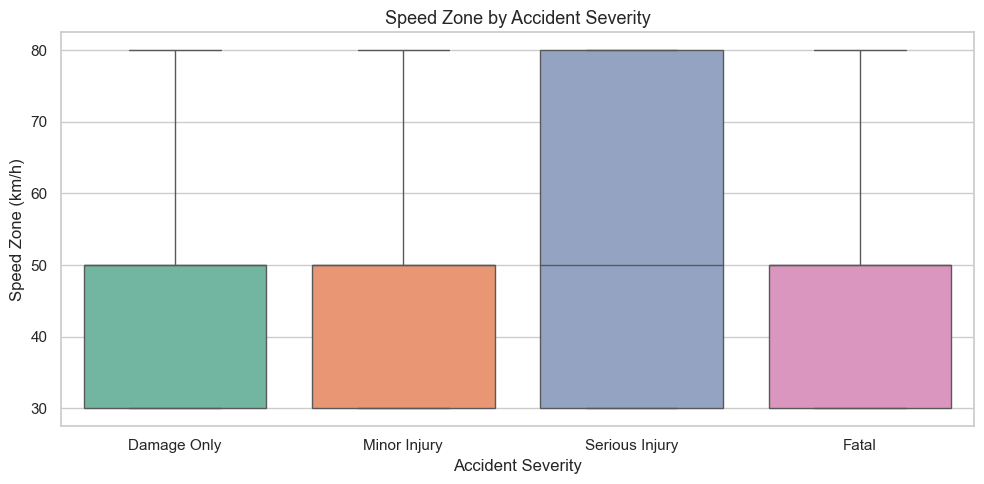

In [16]:
order = ['Damage Only', 'Minor Injury', 'Serious Injury', 'Fatal']

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Accident_Severity', y='Speed_Zone', order=order,
            palette='Set2', ax=ax)
ax.set_title('Speed Zone by Accident Severity', fontsize=13)
ax.set_xlabel('Accident Severity')
ax.set_ylabel('Speed Zone (km/h)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'speedzone_by_severity.png', dpi=150)
plt.show()

## 11. Yearly Accident Trend (Line Chart)

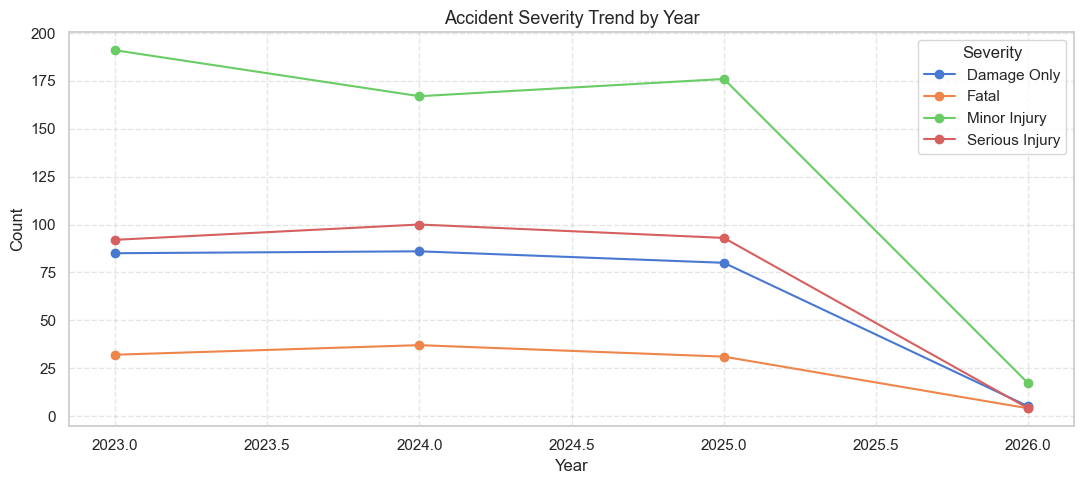

In [17]:
yearly = df.groupby(['Year', 'Accident_Severity']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
for col in yearly.columns:
    ax.plot(yearly.index, yearly[col], marker='o', label=col)
ax.set_title('Accident Severity Trend by Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend(title='Severity')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
fig.savefig(FIG_DIR / 'yearly_trend.png', dpi=150)
plt.show()

## 12. Normalised Severity % by Province (100% Stacked Bar)

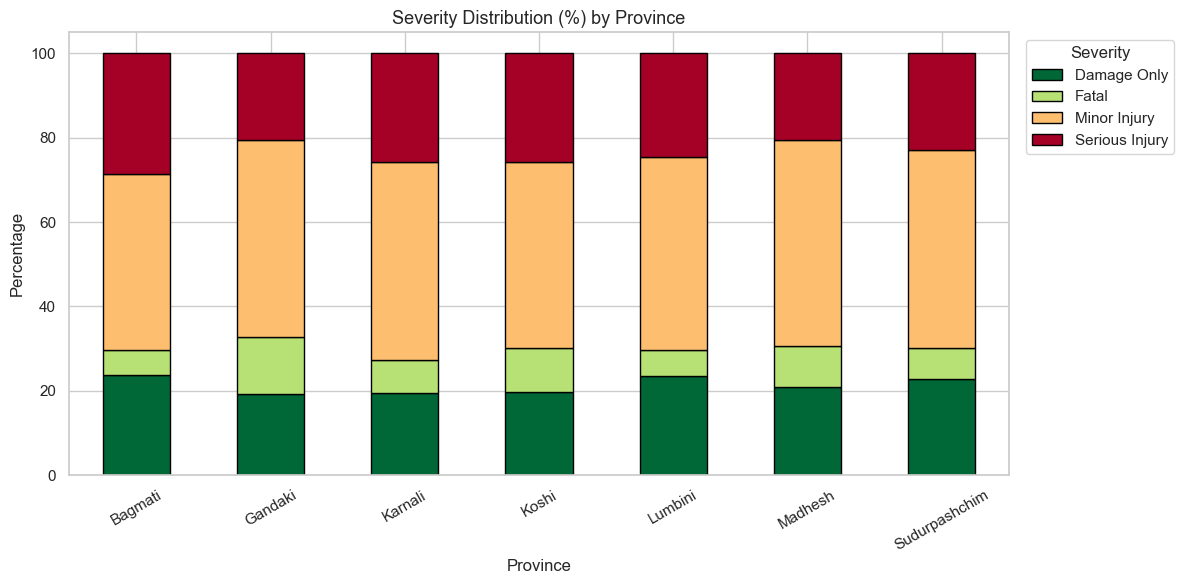

In [12]:
prov_norm = df.groupby(['Province','Accident_Severity']).size().unstack(fill_value=0)
prov_norm = prov_norm.div(prov_norm.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
prov_norm.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r', edgecolor='black')
ax.set_title('Severity Distribution (%) by Province', fontsize=13)
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Severity', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
fig.savefig(FIG_DIR / 'province_severity_pct.png', dpi=150)
plt.show()

## 13. Top 15 Districts — Fatal & Serious Injury Rate

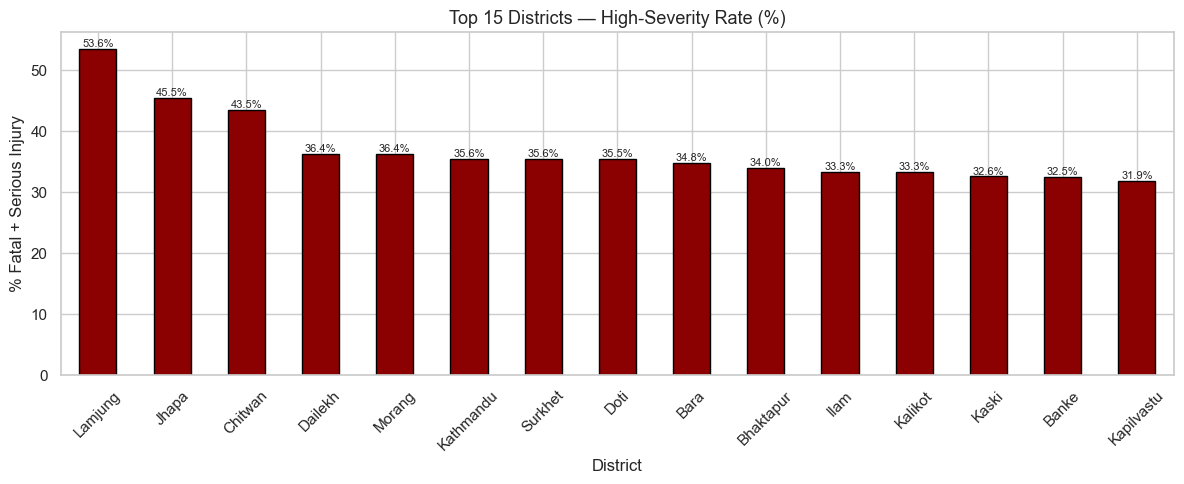

In [18]:
dist_total = df.groupby('District').size()
dist_high  = df[df['Accident_Severity'].isin(['Fatal','Serious Injury'])].groupby('District').size()
dist_rate  = (dist_high / dist_total * 100).dropna().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
dist_rate.plot(kind='bar', color='darkred', edgecolor='black', ax=ax)
ax.set_title('Top 15 Districts — High-Severity Rate (%)', fontsize=13)
ax.set_ylabel('% Fatal + Serious Injury')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(dist_rate):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'district_risk_rate.png', dpi=150)
plt.show()

## 14. Month × Severity Heatmap

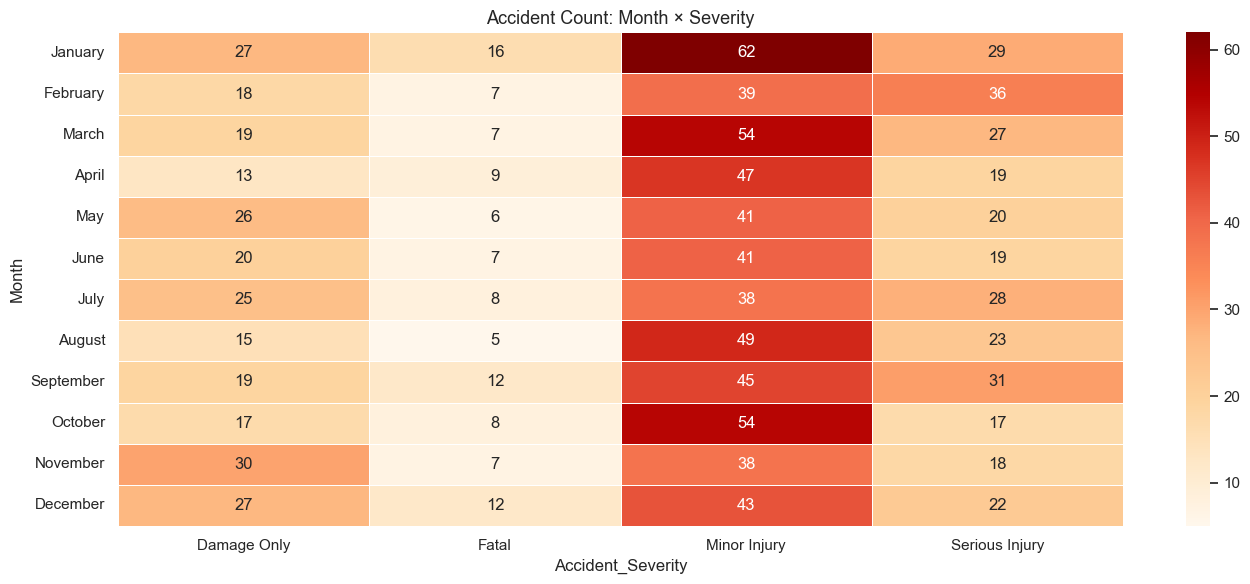

In [19]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot_ms = df.groupby(['Month','Accident_Severity']).size().unstack(fill_value=0)
pivot_ms = pivot_ms.reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_ms, annot=True, fmt='d', cmap='OrRd', linewidths=0.4, ax=ax)
ax.set_title('Accident Count: Month × Severity', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'heatmap_month_severity.png', dpi=150)
plt.show()

## 15. Intersection Type × Time of Day Heatmap

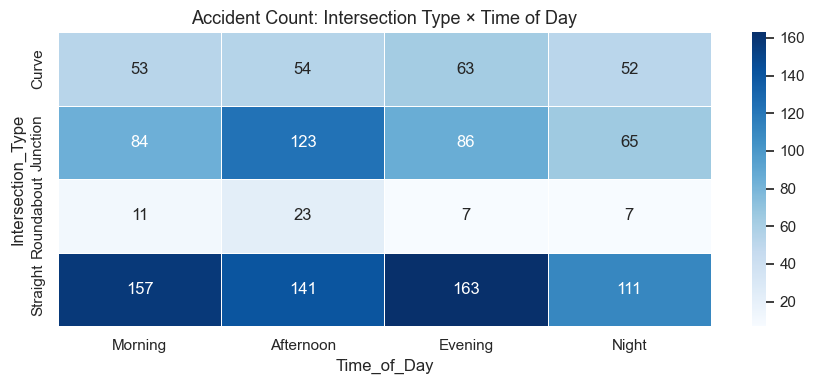

In [20]:
pivot_it = df.groupby(['Intersection_Type','Time_of_Day']).size().unstack(fill_value=0)
tod_order = ['Morning','Afternoon','Evening','Night']
pivot_it = pivot_it.reindex(columns=tod_order, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot_it, annot=True, fmt='d', cmap='Blues', linewidths=0.4, ax=ax)
ax.set_title('Accident Count: Intersection Type × Time of Day', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'heatmap_intersection_time.png', dpi=150)
plt.show()

## 16. Speed Zone KDE — Density by Severity

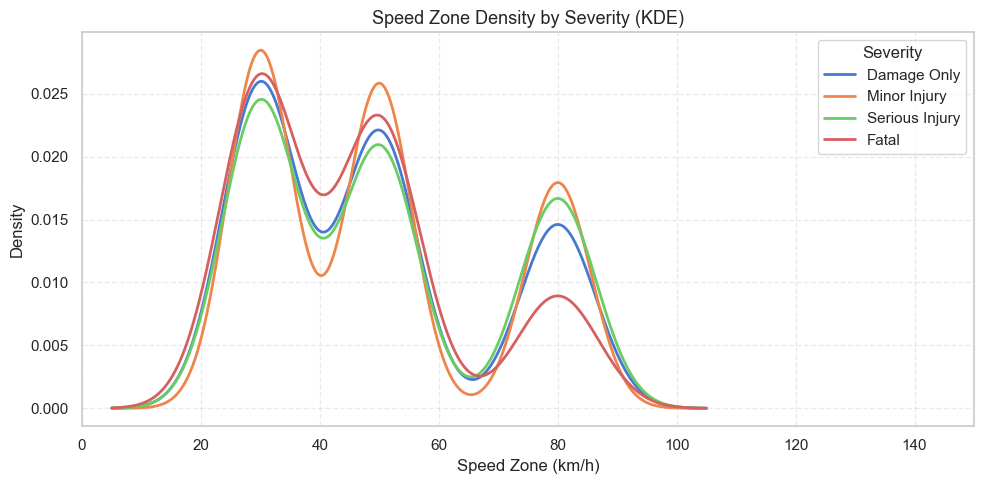

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sev_order = ['Damage Only', 'Minor Injury', 'Serious Injury', 'Fatal']
for sev in sev_order:
    subset = df[df['Accident_Severity'] == sev]['Speed_Zone']
    subset.plot.kde(ax=ax, label=sev, linewidth=2)
ax.set_title('Speed Zone Density by Severity (KDE)', fontsize=13)
ax.set_xlabel('Speed Zone (km/h)')
ax.set_xlim(0, 150)
ax.legend(title='Severity')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
fig.savefig(FIG_DIR / 'speed_kde_severity.png', dpi=150)
plt.show()

## 17. Vehicle Type — Normalised Severity %

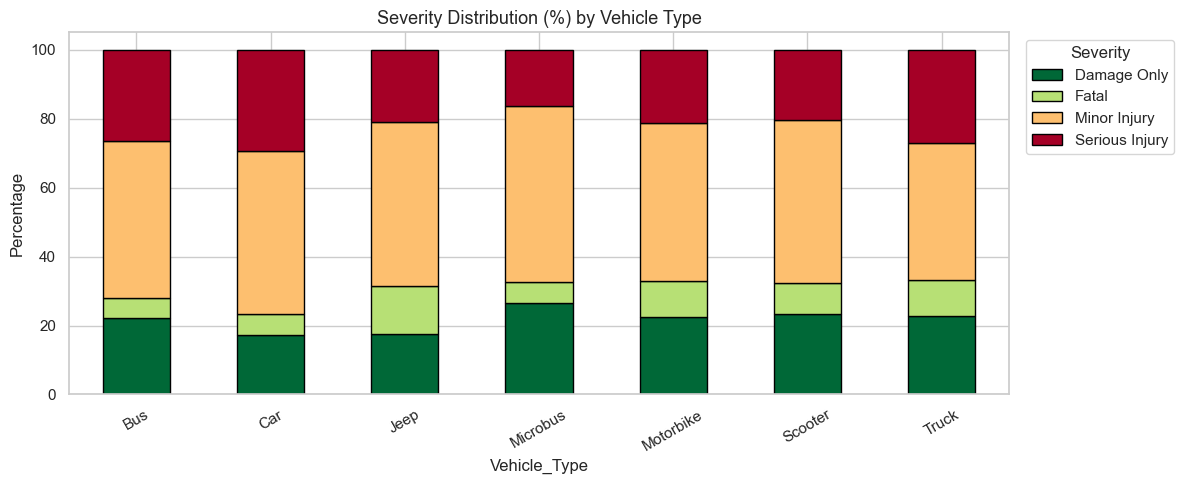

In [22]:
veh_norm = df.groupby(['Vehicle_Type','Accident_Severity']).size().unstack(fill_value=0)
veh_norm = veh_norm.div(veh_norm.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
veh_norm.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r', edgecolor='black')
ax.set_title('Severity Distribution (%) by Vehicle Type', fontsize=13)
ax.set_ylabel('Percentage')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Severity', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
fig.savefig(FIG_DIR / 'vehicle_severity_pct.png', dpi=150)
plt.show()

## 18. Day of Week — Accident Count & Severity

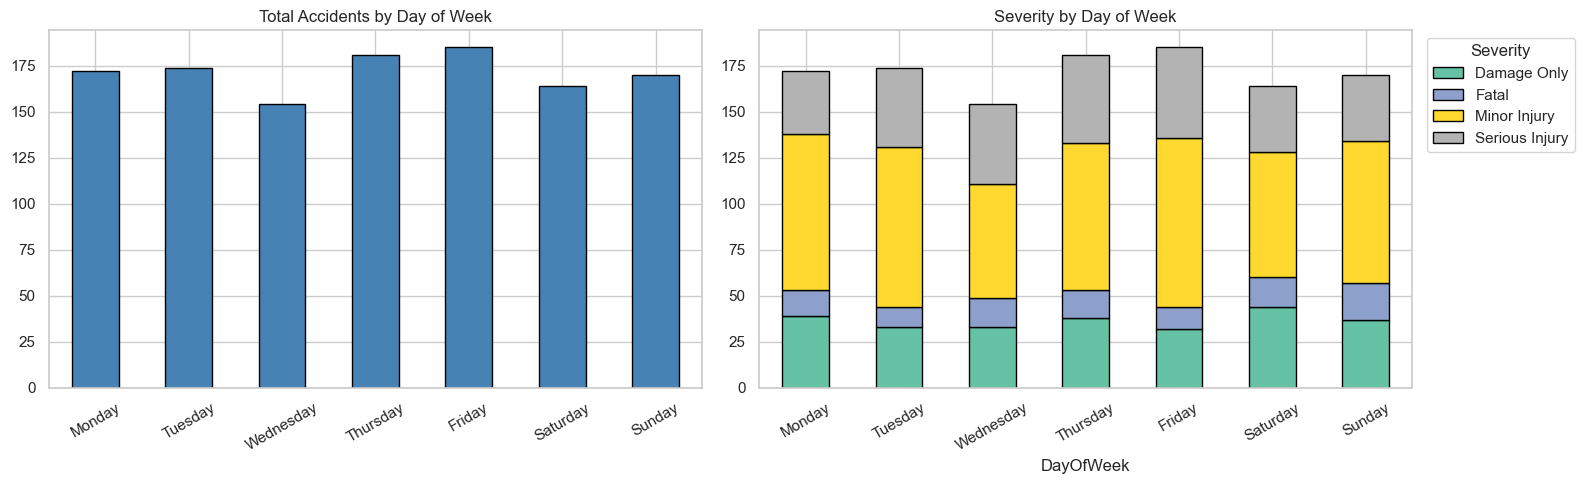

In [23]:
df['Accident_Date'] = pd.to_datetime(df['Accident_Date'], errors='coerce')
df['DayOfWeek'] = df['Accident_Date'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sev = df.groupby(['DayOfWeek','Accident_Severity']).size().unstack(fill_value=0)
day_sev = day_sev.reindex(day_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count bar
day_sev.sum(axis=1).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Total Accidents by Day of Week')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_xlabel('')

# Stacked severity
day_sev.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('Severity by Day of Week')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Severity', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
fig.savefig(FIG_DIR / 'day_of_week_analysis.png', dpi=150)
plt.show()

## 19. Severity Breakdown per Weather Condition (Pie Subplots)

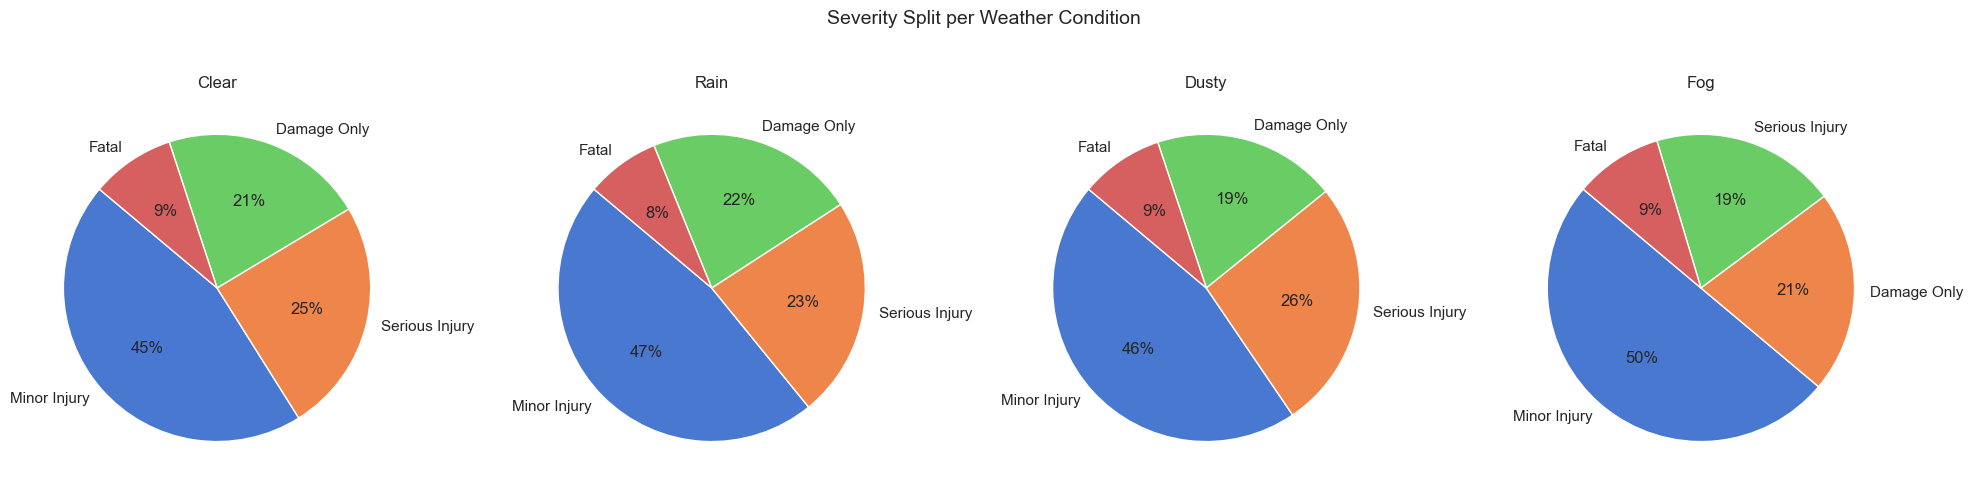

In [25]:
weather_vals = df['Weather_Condition'].value_counts().index.tolist()
fig, axes = plt.subplots(1, len(weather_vals), figsize=(5 * len(weather_vals), 5))
if len(weather_vals) == 1:
    axes = [axes]
colors = sns.color_palette('muted')

for ax, weather in zip(axes, weather_vals):
    subset = df[df['Weather_Condition'] == weather]['Accident_Severity'].value_counts()
    ax.pie(subset, labels=subset.index, autopct='%1.0f%%', colors=colors, startangle=140)
    ax.set_title(f'{weather}', fontsize=12)

plt.suptitle('Severity Split per Weather Condition', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'weather_severity_pies.png', dpi=150)
plt.show()

## 20. Road Type — Fatal Rate % & Province × Road Type Heatmap

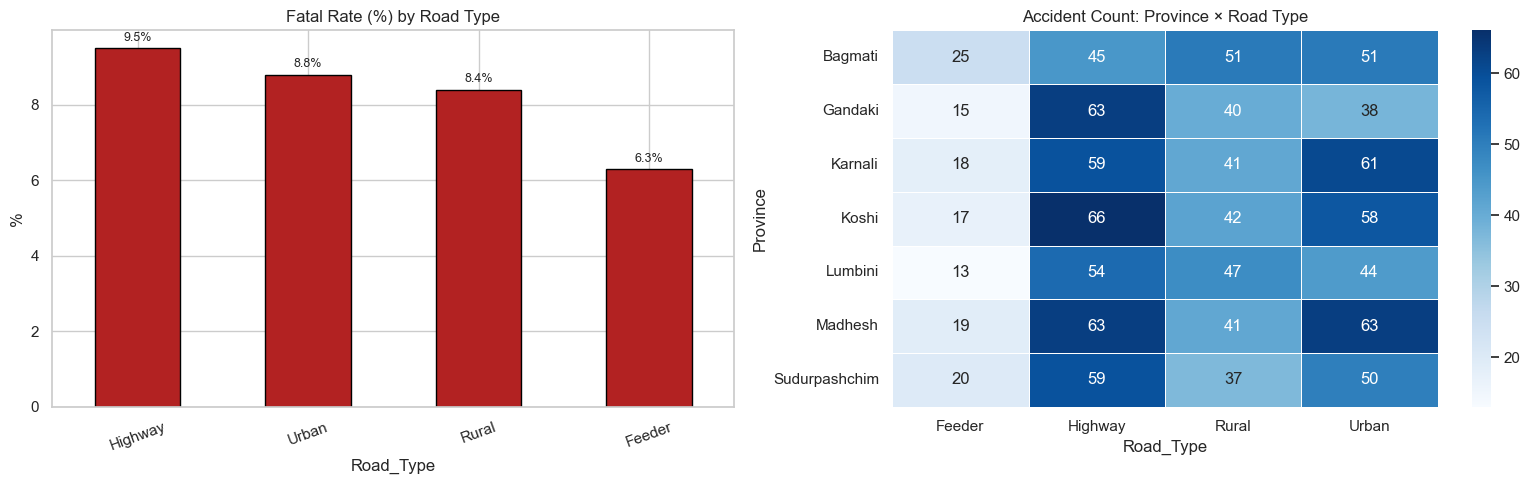

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Road Type fatal rate
rt_total = df.groupby('Road_Type').size()
rt_fatal = df[df['Accident_Severity'] == 'Fatal'].groupby('Road_Type').size()
rt_rate  = (rt_fatal / rt_total * 100).sort_values(ascending=False).round(1)
rt_rate.plot(kind='bar', ax=axes[0], color='firebrick', edgecolor='black')
axes[0].set_title('Fatal Rate (%) by Road Type')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(rt_rate):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontsize=9)

# Province × Road Type heatmap
pivot_pr = df.groupby(['Province','Road_Type']).size().unstack(fill_value=0)
sns.heatmap(pivot_pr, annot=True, fmt='d', cmap='Blues', linewidths=0.4, ax=axes[1])
axes[1].set_title('Accident Count: Province × Road Type')

plt.tight_layout()
fig.savefig(FIG_DIR / 'roadtype_province_analysis.png', dpi=150)
plt.show()

## 21. Driver Gender — Province Breakdown & Overall Split

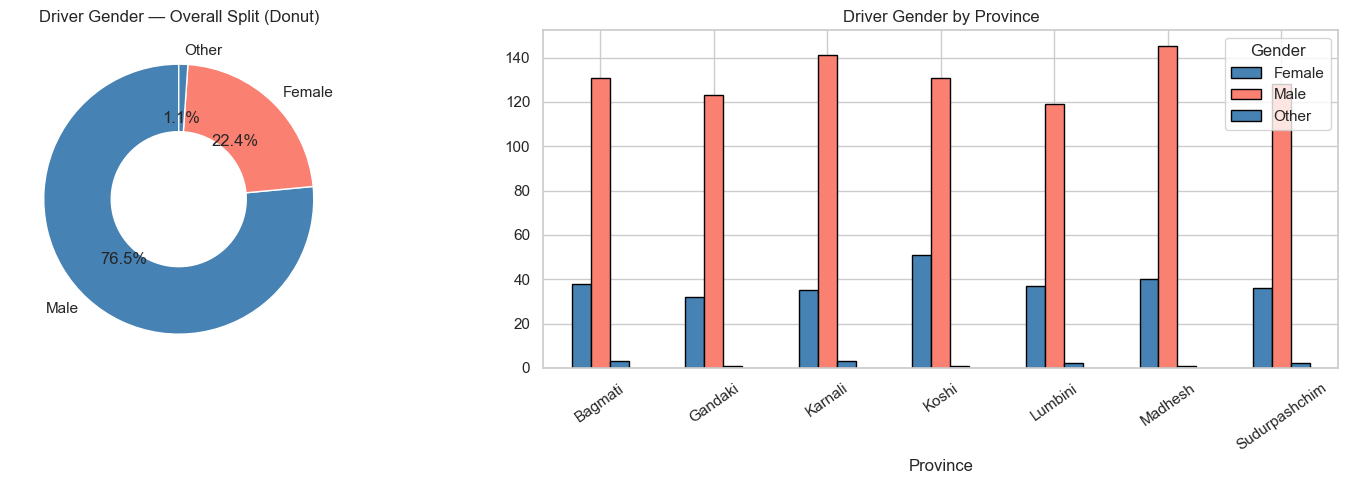

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Donut chart — overall gender split
gender_counts = df['Driver_Gender'].value_counts()
wedge_props = {'width': 0.5}
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['steelblue','salmon'], startangle=90,
            wedgeprops=wedge_props)
axes[0].set_title('Driver Gender — Overall Split (Donut)')

# Grouped bar — gender per province
gp = df.groupby(['Province','Driver_Gender']).size().unstack(fill_value=0)
gp.plot(kind='bar', ax=axes[1], color=['steelblue','salmon'], edgecolor='black')
axes[1].set_title('Driver Gender by Province')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend(title='Gender')

plt.tight_layout()
fig.savefig(FIG_DIR / 'gender_analysis.png', dpi=150)
plt.show()

## 22. Cumulative Accident Count Over Time

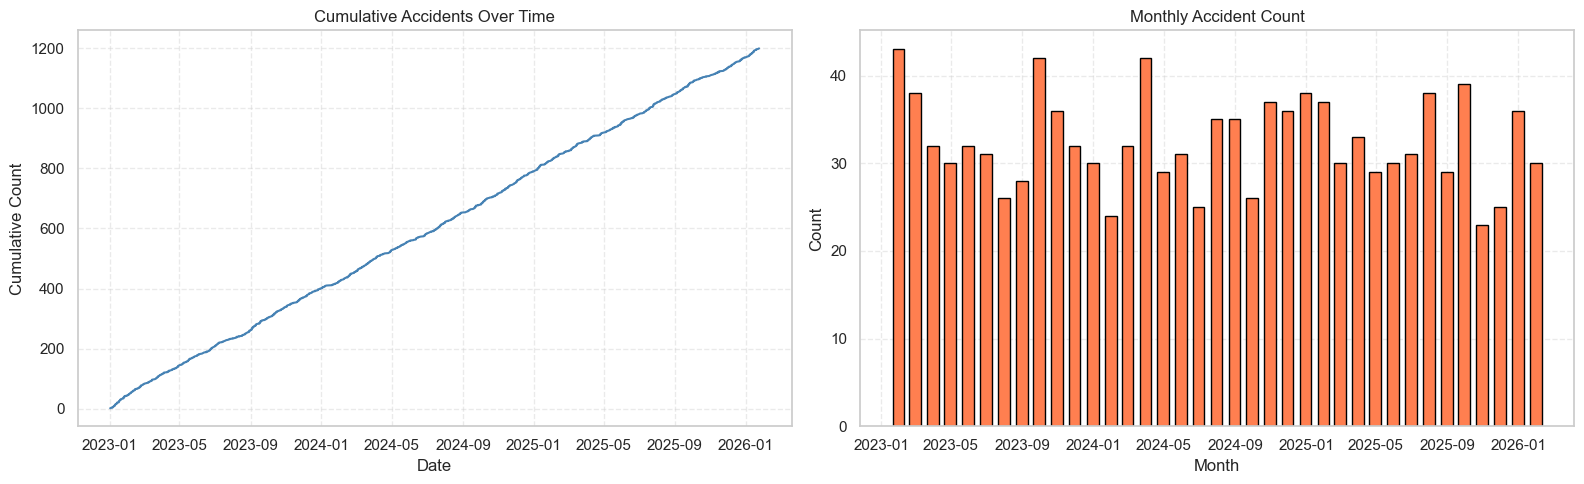

In [28]:
df_dated = df.dropna(subset=['Accident_Date']).copy()
df_dated = df_dated.sort_values('Accident_Date')
df_dated['Cumulative'] = range(1, len(df_dated) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative line
axes[0].plot(df_dated['Accident_Date'], df_dated['Cumulative'], color='steelblue', linewidth=1.5)
axes[0].set_title('Cumulative Accidents Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative Count')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Monthly rolling count
monthly = df_dated.set_index('Accident_Date').resample('ME').size()
axes[1].bar(monthly.index, monthly.values, color='coral', edgecolor='black', width=20)
axes[1].set_title('Monthly Accident Count')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
fig.savefig(FIG_DIR / 'cumulative_trend.png', dpi=150)
plt.show()